In [8]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Create a Sythetic Dataset with 3 features and a Binary Target


In [2]:
n_features = 3
n = 1000
n_classes = 2

X, y = make_classification(
    n_samples = n,               # Number of rows (samples)
    n_features = n_features,      # Number of features
    n_informative = 3,            # Features related to the target
    n_redundant = 0,              # Correlated features
    n_classes = n_classes,        # 2 targets for binary classification
    random_state = 42             # For reproducibility
)

columns = [f"feature{i+1}" for i in range(n_features)]

data = pd.concat([pd.DataFrame(X, columns=columns),
                  pd.Series(y, name='response')], axis=1)

print(data.shape)
data.head()

(1000, 4)


,feature1,feature2,feature3,response
0,0.521706,0.726857,2.504102,1
1,-1.019710,-0.749860,-0.713463,0
2,-1.892225,-1.032171,1.541761,0
3,0.625801,-0.866283,-0.350923,0
4,1.034612,1.641388,3.182540,1


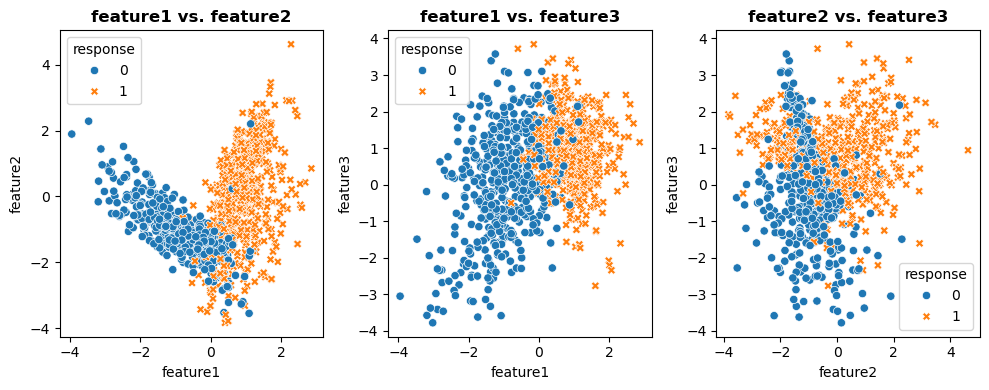

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.scatterplot(
    x="feature1", 
    y="feature2", 
    hue="response",
    style="response", 
    data=data,
    ax=axes[0]
)
axes[0].set_title('feature1 vs. feature2', fontweight='bold')

sns.scatterplot(
    x="feature1", 
    y="feature3", 
    hue="response",
    style="response", 
    data=data,
    ax=axes[1]
)
axes[1].set_title('feature1 vs. feature3', fontweight='bold')

sns.scatterplot(
    x="feature2", 
    y="feature3", 
    hue="response",
    style="response", 
    data=data,
    ax=axes[2]
)
axes[2].set_title('feature2 vs. feature3', fontweight='bold')

plt.tight_layout()
plt.show()

# Logistic Regression by Hand

1)	**Initialize**: Set weights to zero and define a learning rate.
2)	**Predict**: Calculate probabilities using the current weights and the sigmoid function.
3)	**Calculate Gradient**: Determine how much the weights need to change to reduce the loss.
4)	**Update**: Adjust weights by subtracting the gradient multiplied by the learning rate.
5)	**Iterate**: Repeat the process until the loss function stops decreasing significantly and the best weights and intercepts are found.


In [4]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 3)
(200, 3)
(800,)
(200,)


In [11]:
class LogisticRegression:
    def __init__(self, learning_rate, n_iterations=1000, threshold=0.5):
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Calculate Gradient - gradient descent
        for _ in range(self.n_iters):
            # start with linear regression calculation
            lm = np.dot(X, self.weights) + self.bias
            # transform model using sigmoid function
            y_pred = self.sigmoid(lm)

            # Update weights and bias
            # for weights X (y_pred - y)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            self.weights -= self.lr * dw
            # for bias (y_pred - y)
            db = (1 / n_samples) * np.sum(y_pred - y)
            self.bias -= self.lr * db


    def predict_prob(self, X):
        lm = np.dot(X, self.weights) + self.bias
        return self.sigmoid(lm)

    def predict_class(self, X, threshold):
        predicted_class = [1 if i >= threshold else 0 for i in self.predict_prob(X)]
        return np.array(predicted_class)
    
            
    

In [12]:
lr_model_hand = LogisticRegression(learning_rate = 0.1, n_iterations = 1000, threshold = 0.65)
lr_model_hand.fit(x_train, y_train)

In [13]:
predictions_hand = lr_model_hand.predict_class(x_test, threshold=0.65)
accuracy_hand = accuracy_score(y_test, predictions_hand)

print(f"Hand Model Accuracy: {accuracy_hand:.2f}")

Hand Model Accuracy: 0.93


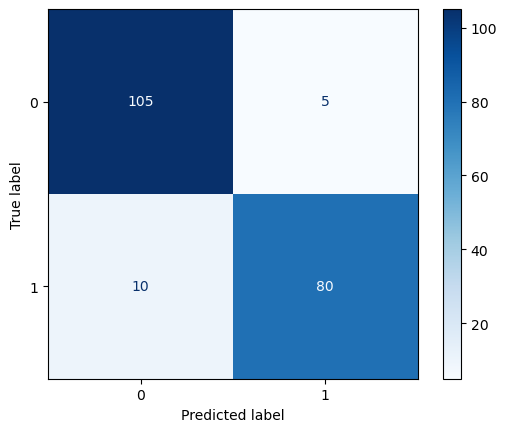

In [14]:
cm_lr_hand = confusion_matrix(y_test, predictions_hand)

tn, fp, fn, tp = cm_lr_hand.ravel()

disp_cm_hand = ConfusionMatrixDisplay(confusion_matrix=cm_lr_hand, display_labels=['0', '1'])
disp_cm_hand.plot(cmap=plt.cm.Blues)
plt.show()

## Logistic Regression Sklearn's Built-in Model
**Imoprtant Note** 

Scikit-learn's optimization method for LogisticRegression does not have a learning rate hyperparameter. The paramaet 'C' is the inverse of regularization strength. 

Example of tunning C parameter:

https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_path.html#sphx-glr-auto-examples-linear-model-plot-logistic-path-py

In [9]:
lr_model_skl = LogisticRegression(
    max_iter=1000,   
    C=0.95,           # regularization strength
    solver='lbfgs'   
)
lr_model_skl.fit(x_train, y_train)

# Predict with threshold set to 0.65
probs_skl = lr_model_skl.predict(x_test)
predictions_skl = (probs_skl >= 0.65).astype(int)
accuracy_skl = accuracy_score(y_test, predictions_skl)

print(f"Skleanr Model Accuracy: {accuracy_skl:.2f}")

Skleanr Model Accuracy: 0.91


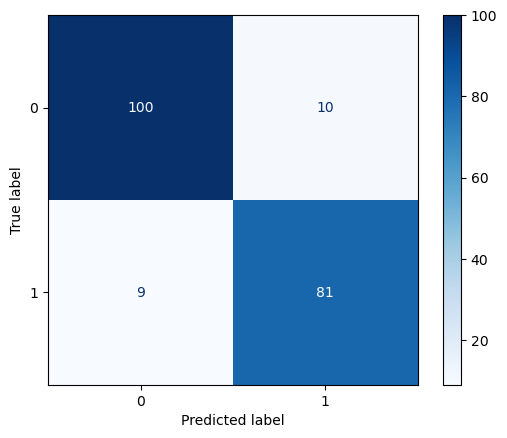

In [10]:
cm_lr_skl = confusion_matrix(y_test, predictions_skl)

disp_cm_skl = ConfusionMatrixDisplay(confusion_matrix=cm_lr_skl, display_labels=['0', '1'])
disp_cm_skl.plot(cmap=plt.cm.Blues)
plt.show()

# References

Claire Longo a.k.a. statisticianinstilettos

https://github.com/statisticianinstilettos/DIY_Logistic_Regression/blob/master/Logistic%20Regression%20by%20Hand.ipynb

https://medium.com/@ilmunabid/basic-multi-class-logistic-regression-from-scratch-in-python-b455a3b0f32d

https://developer.ibm.com/articles/implementing-logistic-regression-from-scratch-in-python/

Updating weights through gradient descent

https://medium.com/mitb-for-all/a-worked-example-on-updating-weights-by-gradient-descent-9a12181ed2b9

Creating synthetic datasets

https://medium.com/data-science/simple-ways-to-create-synthetic-dataset-in-python-76a8e9a2f35c